Task 1: Git, GitHub, and Exploratory Data Analysis

Descriptive Statistics

In [2]:

import pandas as pd

df = pd.read_csv("../data/raw_analyst_ratings.csv")

df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

df.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87


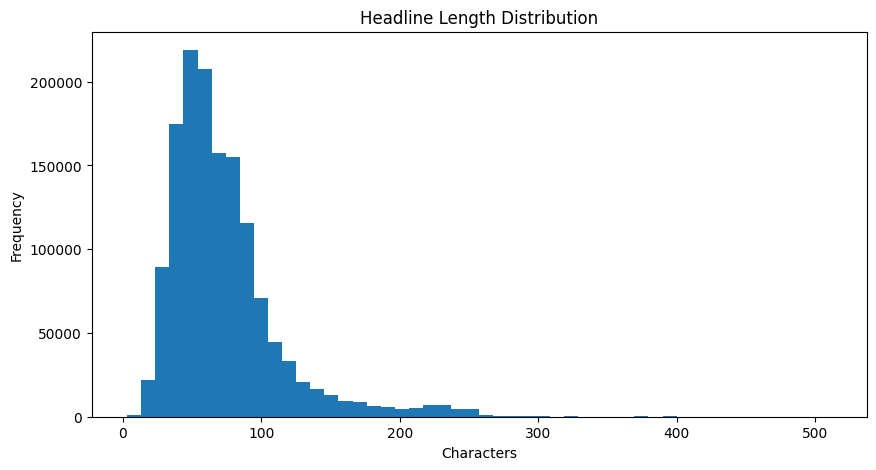

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['headline_length'], bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

Publisher Analysis

In [7]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(50)

publisher
Paul Quintaro           228373
Lisa Levin              186979
Benzinga Newsdesk       150484
Charles Gross            96732
Monica Gerson            82380
Eddie Staley             57254
Hal Lindon               49047
ETF Professor            28489
Juan Lopez               28438
Benzinga Staff           28114
Vick Meyer               24826
webmaster                20313
Benzinga_Newsdesk        19410
Zacks                    19390
Jayson Derrick           19050
Allie Wickman            18317
Shanthi Rexaline         16640
Craig Jones              16221
Wayne Duggan             12897
Nelson Hem               12590
Dwight Einhorn           12226
Michael J. Zerinskas     10892
Joe Young                10777
Javier Hasse              8839
David Johnson             8749
Matthew Kennedy           8167
Forex Live                7198
Laura Brodbeck            7069
Scott Rubin               6553
Jake L'Ecuyer             5810
Roger Nachman             5510
luke@benzinga.com         519

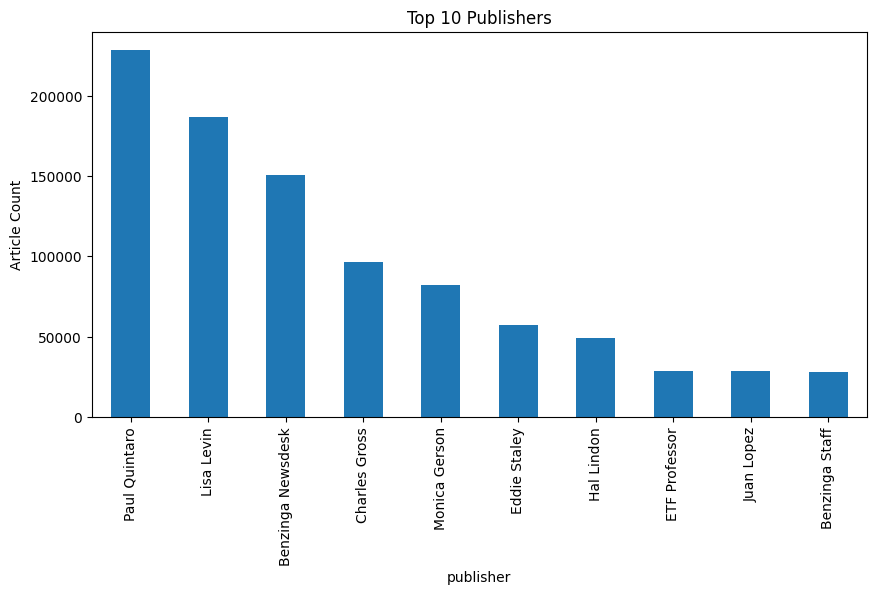

In [8]:
publisher_counts.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Publishers")
plt.ylabel("Article Count")
plt.show()

Based on the above analysis and visualization the most active publisher is Paul Quintaro with 228373 articles.

Date Analysis

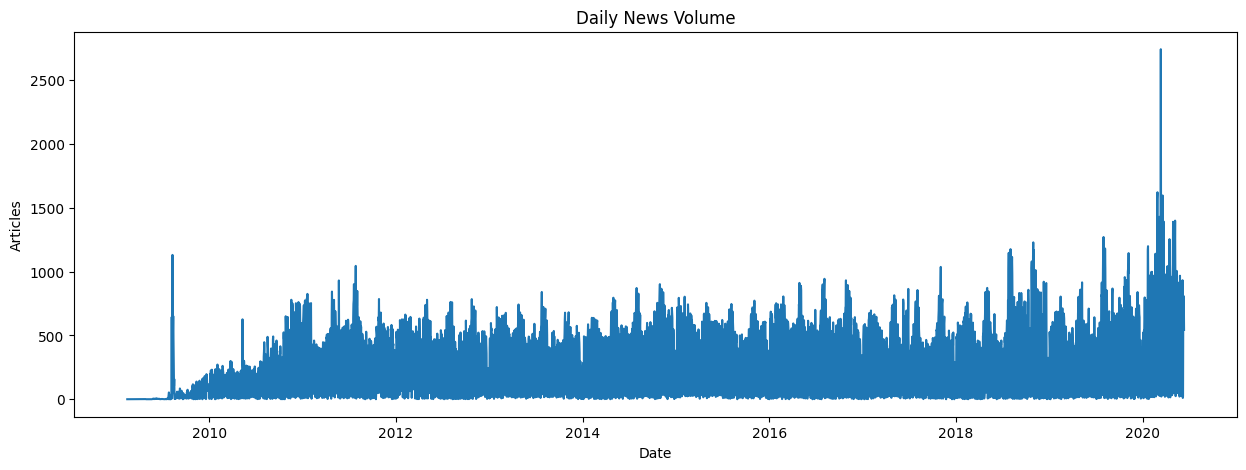

In [14]:
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

daily_news = df.groupby(df['date'].dt.date).size()

daily_news.plot(figsize=(15,5))

plt.title("Daily News Volume")
plt.xlabel("Date")
plt.ylabel("Articles")
plt.show()

Based on the above analysis almost all spikes happened aaround specific market events forexample the first spike around 2009 was most probably because of the Global Financial Crisis and the last spike as shown in the graph was around 2020 which was caused by covid-19 pandemic.

Text Analysis 

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2,2),  
    max_features=20
)

X = vectorizer.fit_transform(df['headline'].astype(str))

phrases = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

phrase_df = pd.DataFrame({
    'phrase': phrases,
    'count': counts
}).sort_values(by='count', ascending=False)

phrase_df

,phrase,count
0,52 week,51006
10,price target,47274
16,stocks moving,40044
8,mid day,37324
7,market update,33101
4,earnings scheduled,32055
5,initiates coverage,28993
9,pre market,28393
14,raises pt,27213
3,companies trading,23170


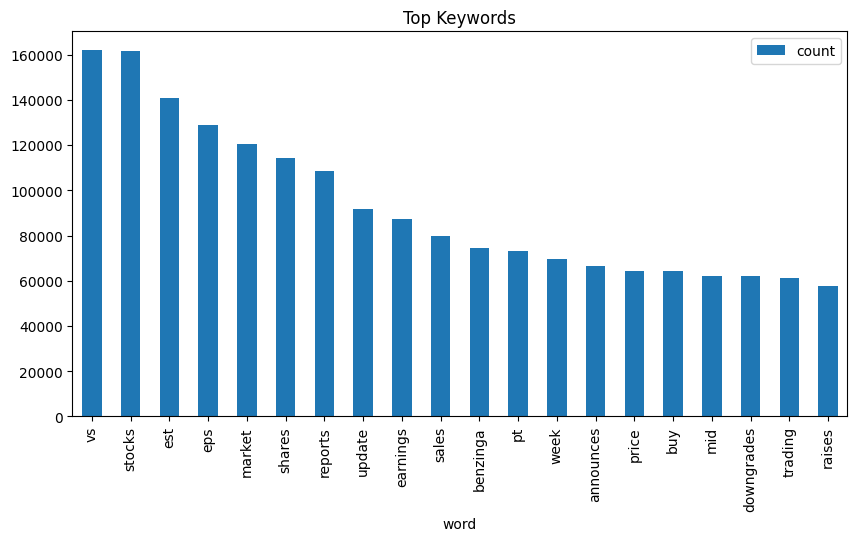

In [17]:
keyword_df.plot(
    x='word',
    y='count',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Keywords")
plt.show()

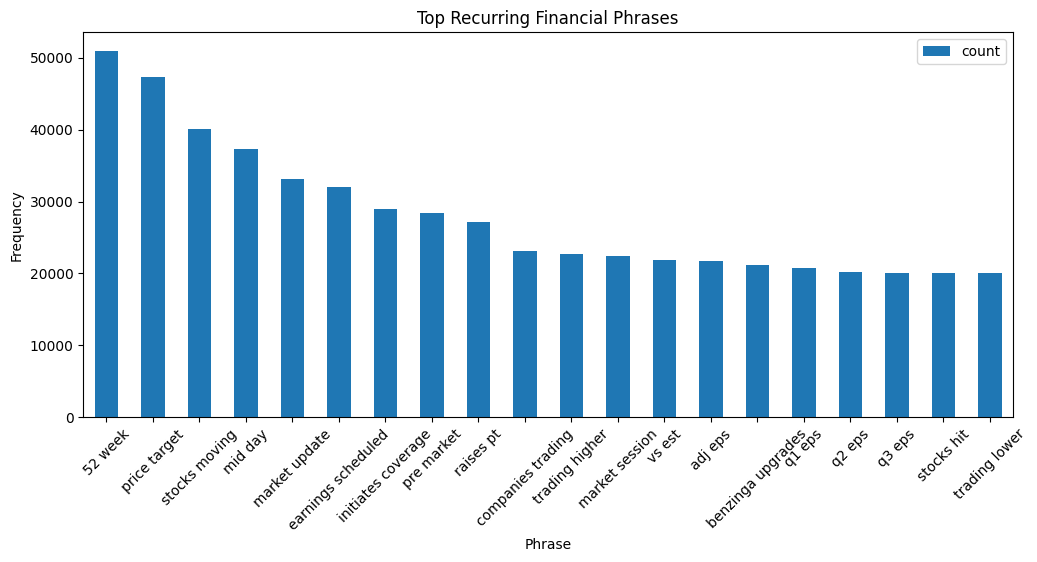

In [23]:
import matplotlib.pyplot as plt

phrase_df.plot(
    x='phrase',
    y='count',
    kind='bar',
    figsize=(12,5)
)

plt.title("Top Recurring Financial Phrases")
plt.xlabel("Phrase")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

Time Series Analysis of News Volume

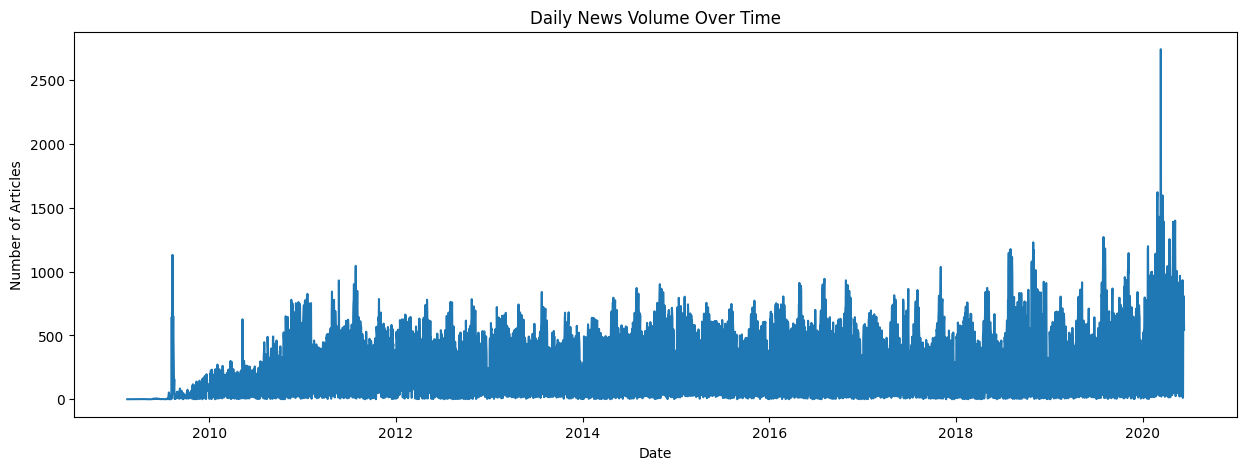

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

df = df.dropna(subset=['date'])
daily_news = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15,5))

daily_news.plot()

plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [27]:
daily_news.sort_values(ascending=False).head(100)


date
2020-03-12    2739
2020-02-28    1620
2020-03-19    1595
2020-02-27    1567
2020-03-06    1428
              ... 
2020-04-13     906
2018-12-19     905
2016-08-03     903
2020-04-22     902
2014-10-30     901
Length: 100, dtype: int64

 Period     Possible Market Event            
 
 2009       Global Financial Crisis recovery 
 
 2011       European Debt Crisis             
 
 2018–2019  US-China Trade War               
 
 2020       COVID-19 pandemic                


In [ ]:
df['hour'] = df['date'].dt.hour
hourly_news = df['hour'].value_counts().sort_index()
hourly_news


hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
Name: count, dtype: int64

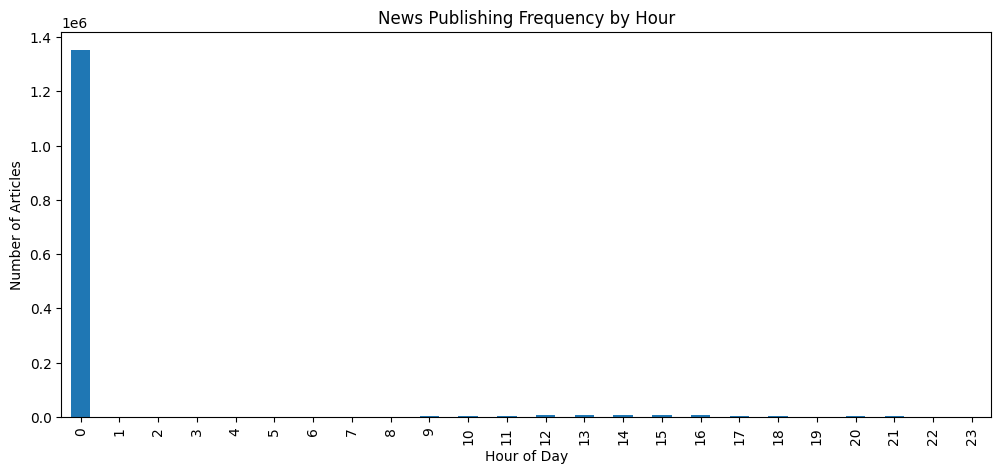

In [29]:
plt.figure(figsize=(12,5))

hourly_news.plot(kind='bar')

plt.title("News Publishing Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.show()

Publisher Analysis

In [31]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(20)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

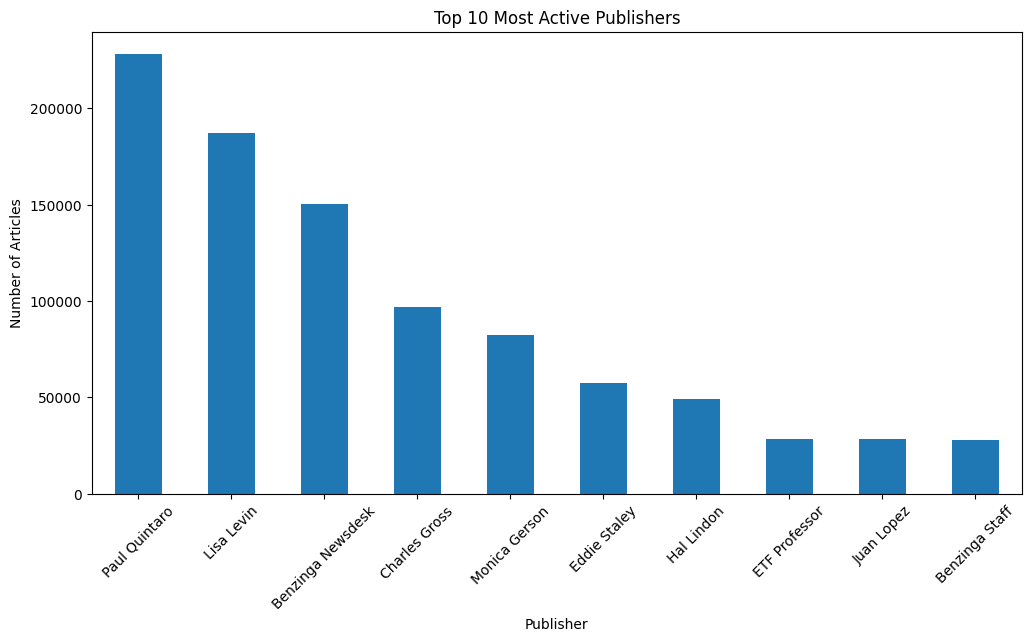

In [32]:
plt.figure(figsize=(12,6))

publisher_counts.head(10).plot(kind='bar')

plt.title("Top 10 Most Active Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

In [48]:
top_publishers = df['publisher'].value_counts().head(5).index
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_headline'] = df['headline'].apply(clean_text)

from collections import Counter

def get_top_words(data, n=15):
    words = " ".join(data).split()
    return Counter(words).most_common(n)

publisher_topics = {}

for pub in top_publishers:
    headlines = df[df['publisher'] == pub]['clean_headline']
    publisher_topics[pub] = get_top_words(headlines)



def classify_topic(words):
    word_list = [w[0] for w in words]

    if any(w in word_list for w in ['election','government','minister','policy']):
        return "Politics-focused"
    if any(w in word_list for w in ['market','stock','economy','trade']):
        return "Business/Economy-focused"
    if any(w in word_list for w in ['sport','game','win','team']):
        return "Sports-focused"
    if any(w in word_list for w in ['tech','ai','software','data']):
        return "Tech-focused"
    
    return "Mixed/General news"

for pub, words in publisher_topics.items():
    print(pub, "→", classify_topic(words))

Paul Quintaro → Mixed/General news
Lisa Levin → Business/Economy-focused
Benzinga Newsdesk → Mixed/General news
Charles Gross → Mixed/General news
Monica Gerson → Business/Economy-focused


In [41]:
df[df['publisher'].str.contains('@', na=False)].head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,hour
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 15:23:25+00:00,A,71,15
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 13:36:20+00:00,A,73,13
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 12:37:59+00:00,A,84,12
11,11,SVB Leerink Maintains Outperform on Agilent Te...,https://www.benzinga.com/news/20/05/16092270/s...,vishwanath@benzinga.com,2020-05-22 00:00:00+00:00,A,84,0
22,22,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/04/15897306/u...,vishwanath@benzinga.com,2020-04-28 00:00:00+00:00,A,73,0


In [44]:
email_publishers = df[df['publisher'].str.contains('@', na=False)].copy()

email_publishers['domain'] = email_publishers['publisher'].str.split('@').str[-1]

domain_counts = email_publishers['domain'].value_counts()

domain_counts.head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64